In [1]:
# jax ecosystem
import jax

# jax.config.update("jax_enable_x64", False)
jax.config.update("jax_enable_x64", True)
jax.config.update("jax_platform_name", "gpu")
# jax.config.update("jax_debug_nans", True)

device = jax.local_devices()[0]
print(device.device_kind)

# stats = device.memory_stats()
# free = stats["bytes_limit"] - stats["bytes_in_use"]
# print(f"Total VRAM : {stats['bytes_limit'] / 1024**3:.2f} GB")
# print(f"In use     : {stats['bytes_in_use'] / 1024**3:.2f} GB")
# print(f"Free       : {free / 1024**3:.2f} GB")

import jax.numpy as np
import jax.tree as jtu
import jax.random as jr

# amigo
import amigo
import dorito
import zodiax
import dLux as dl
import abcdLux

# matplotlib ecosystem
import matplotlib.pyplot as plt
import matplotlib as mpl
import ehtplot
import scienceplots

# other
import pandas as pd
import os
import sys

# matplotlib parameters
plt.style.use(["science", "bright", "no-latex"])
plt.rcParams["image.cmap"] = "inferno"
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = "lower"
plt.rcParams["figure.dpi"] = 300
plt.rcParams["font.size"] = 8
plt.rcParams["xtick.direction"] = "out"
plt.rcParams["ytick.direction"] = "out"

inferno = mpl.colormaps["inferno"]
seismic = mpl.colormaps["seismic"]
coolwarm = mpl.colormaps["coolwarm"]

inferno.set_bad("k", 0.5)
seismic.set_bad("k", 0.5)
coolwarm.set_bad("k", 0.5)

if jax.config.read("jax_enable_x64"):
    print("64bit enabled")
else:
    print("32bit enabled")

import equinox
import lineax

print("jax version:", jax.__version__)
print("zodiax version:", zodiax.__version__)
print("dLux version:", dl.__version__)
print("amigo version:", amigo.__version__)
print("dorito version:", dorito.__version__)
print("equinox version:", equinox.__version__)
print("lineax version", lineax.__version__)
print("abcdLux version", abcdLux.__version__)

NVIDIA H200
64bit enabled
jax version: 0.8.3
zodiax version: 0.5.0
dLux version: 0.14.1
amigo version: 0.0.10
dorito version: 0.2.0
equinox version: 0.13.7
lineax version 0.1.0
abcdLux version 0.0.2


In [2]:
from socket import gethostname

print(gethostname())
if gethostname().startswith("max-"):
    path = "/home/dgxuser/max/"
elif (
    gethostname() == "maxs-mbp-14.shared.sydney.edu.au"
    or gethostname() == "Maxs-MacBook-Pro-14.local"
):
    path = "/Volumes/morgana1/snert/max/"
    # path = "/Volumes/research-data/PRJ-PAT/max/"
else:
    path = "/fred/oz440/max/"

source_name = "PDS70"
data_path = os.path.join(path, f"data/JWST/{source_name}/calslope/")
uncal_path = os.path.join(path, f"data/JWST/{source_name}/uncal/")
amigo_cache = os.path.join(path, "data/amigo_files/")

cache = os.path.join(amigo_cache, "v_0.0.10/")
output_path = os.path.join(amigo_cache, f"outputs/{source_name}/")

EXP_TYPE = "NIS_AMI"
FILTERS = [
    "F480M",
    "F430M",
    "F380M",
    # "F277W",
]

# Bind file path, type and exposure type
file_fn = lambda data_path, filters=FILTERS, **kwargs: amigo.files.get_files(
    data_path,
    "calslope",
    EXP_TYPE=EXP_TYPE,
    FILTER=filters,
    **kwargs,
)

max-imagev2-0-26


In [3]:
files = sorted(
    file_fn(data_path), key=lambda hdu: hdu[0].header.get("EXPMID", float("inf"))
)
sci_files = []
cal_files = []

for file in files:

    # manual bad pixel correction
    file["BADPIX"].data[58, 67] = 1
    file["BADPIX"].data[71, 22] = 1
    file["BADPIX"].data[65, 41] = 1
    file["BADPIX"].data[35, 70] = 1
    file["BADPIX"].data[70, 55] = 1
    file["BADPIX"].data[5, 5] = 1
    file["BADPIX"].data[-4, 37] = 1
    file["BADPIX"].data[51, 27] = 1
    file["BADPIX"].data[28, 18] = 1
    file["BADPIX"].data[32, 10] = 1

    file["BADPIX"].data[:, :3] = 1
    file["BADPIX"].data[:, -3:] = 1
    file["BADPIX"].data[:3, :] = 1
    file["BADPIX"].data[-3:, :] = 1

    if file[0].header["TARGPROP"] == "TD-PDS-70":
        continue

    elif bool(file[0].header["IS_PSF"]):
        # file[0].header["TARGPROP"] = "HD228337"
        cal_files.append(file)
    else:
        print(f"Unkown target: {file[0].header['TARGPROP']}")

# dorito.misc.truncate_files(sci_files, 30)

In [4]:
from astropy.time import Time

t0 = Time(0, format="mjd")
for file in files:
    h = file[0].header
    t = Time(h["EXPMID"], format="mjd")

    if t.ymdhms[2] != t0.ymdhms[2]:
        print("\n" + 30 * "-" + "\n")

    print(
        f'{h["TARGPROP"]} {h["FILTER"]}, Dither {h["PATT_NUM"]}/{h["NUMDTHPT"]}, Roll {h["ROLL_REF"]:.1f}deg, {h["XPOSURE"] / 60:.1f}min, {t.iso}, Groups: {h["NGROUPS"]}, Ints: {h["NINTS"]}, PWCPOS {h["PWCPOS"]}'
    )
    t0 = t


------------------------------

TD-CAL-HD-123991 F480M, Dither 1/1, Roll 302.2deg, 15.2min, 2023-02-24 19:20:07.785, Groups: 29, Ints: 418, PWCPOS 205.0233309999992
TD-CAL-HD-123991 F430M, Dither 1/1, Roll 302.2deg, 12.7min, 2023-02-24 19:36:30.612, Groups: 20, Ints: 507, PWCPOS 205.0233309999996
TD-CAL-HD-123991 F380M, Dither 1/1, Roll 302.2deg, 7.7min, 2023-02-24 19:49:00.589, Groups: 10, Ints: 612, PWCPOS 205.02333100000027
TD-PDS-70 F480M, Dither 1/1, Roll 301.7deg, 50.5min, 2023-02-24 21:05:08.000, Groups: 96, Ints: 418, PWCPOS 204.98422199999922
TD-PDS-70 F430M, Dither 1/1, Roll 301.7deg, 40.4min, 2023-02-24 21:52:27.644, Groups: 64, Ints: 502, PWCPOS 204.98666399999735
TD-PDS-70 F380M, Dither 1/1, Roll 301.7deg, 36.8min, 2023-02-24 22:33:15.992, Groups: 49, Ints: 597, PWCPOS 204.99400000000205


/home/dgxuser/max/conda/envs/retrain/lib/python3.12/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "d2dtf" yielded 1 of "dubious year (Note 5)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)


In [5]:
from dLux import utils as dlu
from dLux.detectors import LayeredDetector
from dLux.layers.detector_layers import DetectorLayer
from amigo.misc import interp


class Resample(DetectorLayer):
    rotation: float
    anisotropy: np.ndarray

    def __init__(self, rotation=0.0, anisotropy=1.00765):
        self.rotation = np.array(rotation, float)
        self.anisotropy = np.array(anisotropy, float)

    def apply(self, psf):
        angle = dlu.deg2rad(self.rotation)
        coords = dlu.pixel_coords(psf.data.shape[0], 2)
        rot_coords = dlu.rotate_coords(coords, angle)
        sample_coords = rot_coords * np.array([1.0, self.anisotropy])[:, None, None]
        # TODO: Test different interpolation methods
        return psf.set("data", interp(psf.data, coords, sample_coords, "cubic2"))

    def __call__(self, psf):
        return self.apply(psf)


class LinearDetector(LayeredDetector):
    def __init__(
        self,
        rot_angle=+0.56126717,
        anisotropy=1.00765,
        jitter=0.0214,
        kernel_size=11,
        kernel_osamp=5,
    ):
        super().__init__(
            [
                ("jitter_model", dl.ApplyJitter(jitter, kernel_size, kernel_osamp)),
                ("resampler", Resample(rotation=rot_angle, anisotropy=anisotropy)),
            ]
        )

In [6]:
from abc import abstractmethod
from jax import vmap, Array
from jax.scipy.signal import convolve
import equinox as eqx
from importlib import resources


def gen_fourier_signal(single_ramp, coeffs, period=1024):
    orders = np.arange(len(coeffs)) + 1
    xs = vmap(lambda order: order * 2 * np.pi * single_ramp / period)(orders)
    basis = np.vstack([np.sin(xs), np.cos(xs)])
    return np.dot(coeffs.flatten(), basis)


class ReadLayer(DetectorLayer):

    @abstractmethod
    def apply(self, ramp):
        pass

    def __call__(self, ramp):
        return self.apply.ramp


class DarkCurrent(ReadLayer):
    dark_current: Array

    def __init__(self, dark_current):
        self.dark_current = np.array(dark_current, float)

    def apply(self, ramp):
        dark_current = self.dark_current * (np.arange(len(ramp.data)) + 1)
        # dark_current = model_dark_current(self.dark_current, len(ramp.data))
        return ramp.add("data", dark_current[..., None, None])


class IPC(ReadLayer):
    ipc: Array

    def __init__(self, ipc):
        self.ipc = np.array(ipc, float)

    def apply(self, ramp):
        conv_fn = lambda x: convolve(x, self.ipc, mode="same")
        return ramp.set("data", vmap(conv_fn)(ramp.data))

    def __call__(self, ramp):
        return self.apply(ramp)


class PixelNonLinearity(ReadLayer):
    """Assumes that the bias has already been added to the ramp"""

    non_linearity: jax.Array
    gain: jax.Array

    def __init__(self, gain=1.61, poly_order=2):
        self.gain = np.array(gain, float)
        self.non_linearity = np.zeros((poly_order - 1, 80, 80))

    def apply(self, ramp):
        # Get the non-linear, per-pixel gain form voltage to counts
        # Assumes that bias has already been added back into the ramp
        # the ramp here is actually the _voltage_ in each pixel
        electrons = ramp.data / 2**16
        # coeffs = self.non_linearity.at[-1].add(np.ones_like(data[0]))

        shape = (1, *electrons.shape[-2:])
        coeffs = np.concatenate(
            [self.non_linearity, np.ones(shape), np.zeros(shape)], axis=0
        )
        # coeffs = np.concatenate([coeffs, np.zeros((1, *data.shape[-2:]))], axis=0)
        counts = np.polyval(coeffs, electrons)
        return ramp.set("data", (counts * 2**16) / self.gain)


class Amplifier(ReadLayer):
    one_on_fs: Array
    axis: int = eqx.field(static=True)

    def __init__(self, one_on_fs=None, axis=1):
        if one_on_fs is not None:
            self.one_on_fs = np.array(one_on_fs, float)
        else:
            self.one_on_fs = None
        self.axis = int(axis)

    def apply(self, ramp):

        if self.one_on_fs is None:
            return ramp

        def read_fn(coeffs):
            xs = np.linspace(-1, 1, coeffs.shape[0])
            return np.rot90(vmap(lambda coeffs: np.polyval(coeffs, xs))(coeffs))

        return ramp.add("data", vmap(read_fn)(self.one_on_fs))


# class ADC(ReadLayer):
#     # TODO: Add the fourier basis into this class, rather than re-generate it. Maybe
#     # make it a new class though, so one can descend on the period
#     ADC_coeffs: Array
#     period: int = eqx.field(static=True)

#     def __init__(self, ADC_coeffs=None, period=1024):
#         if ADC_coeffs is None:
#             ADC_coeffs = np.zeros((1, 2))
#         # if ADC_coeffs[0, 0] == 0:
#         #     ADC_coeffs = ADC_coeffs.at[0, 0].set(1.5)
#         self.ADC_coeffs = np.array(ADC_coeffs, float)
#         self.period = int(period)

#     def apply(self, ramp):
#         data = ramp.data
#         apply_fn = vmap(lambda x: gen_fourier_signal(x, self.ADC_coeffs, self.period))
#         correction = apply_fn(data.reshape(len(data), -1).T).T.reshape(data.shape)
#         return ramp.add("data", correction)


class ReadModel(LayeredDetector):

    def __init__(
        self,
        dark_current=0.25,
        ipc=True,
        one_on_fs=None,
        gain=1.61,
    ):

        if ipc:
            # NOTE change this back when actually putting inside amigo package
            # file_path = resources.files(__package__) / "data" / "SUB80_ipc.npy"
            file_path = resources.files("amigo") / "data" / "SUB80_ipc.npy"
            ipc = IPC(np.load(file_path))
        else:
            ipc = None

        super().__init__(
            [
                ("read", DarkCurrent(dark_current)),
                ("IPC", ipc),
                ("pixel_non_linearity", PixelNonLinearity(gain=gain)),
                ("amplifier", Amplifier(one_on_fs)),
            ]
        )

In [12]:
from amigo.misc import calc_throughput, interp
from amigo.optical_models import (
    DynamicApertureMask,
    StaticApertureMask,
    get_initial_holes,
    reduce_basis,
    # propagate_sparse,
    # plane_to_plane,
)


class AMIOptics(dl.AngularOpticalSystem):
    filters: dict
    defocus_type: str
    defocus: np.ndarray
    corners: np.ndarray
    psf_upsample: int

    def __init__(
        self,
        nwavels=9,
        filters=["F380M", "F430M", "F480M"],
        radial_orders=4,
        distortion_orders=3,
        coherence_orders=4,
        oversample=3,
        psf_upsample=3,
        defocus_type="fft",
        #
        pupil_mask=None,
        normalise=True,
        psf_npixels=80,
        psf_pixel_scale=0.065524085,  # mas/pixel?
        diameter=6.603464,
        wf_npixels=1024,
        f2f=0.80,
        oversize=1.2,
        defocus=0.01,
        polike=False,
        static=True,
    ):

        # Instantiate pupil mask layer
        if pupil_mask is None:
            if not static:
                pupil_mask = DynamicApertureMask(
                    distortion_orders=distortion_orders,
                    diameter=diameter,
                    npixels=wf_npixels,
                    f2f=f2f,
                    normalise=normalise,
                    aberration_orders=radial_orders,
                    amplitude_orders=coherence_orders,
                    oversize=oversize,
                    polike=polike,
                )
            else:
                pupil_mask = StaticApertureMask(
                    diameter=diameter,
                    npixels=wf_npixels,
                    f2f=f2f,
                    normalise=normalise,
                    aberration_orders=radial_orders,
                    amplitude_orders=coherence_orders,
                    oversize=oversize,
                    polike=polike,
                )

        # optical layers
        layers = [("InvertY", dl.Flip(0)), ("pupil_mask", pupil_mask)]

        super().__init__(
            wf_npixels,
            diameter,
            layers,
            psf_npixels,
            np.array(psf_pixel_scale),
            oversample,
        )

        if defocus_type not in ["phase", "fft", None]:
            raise ValueError("defocus_type must be one of 'phase', 'fft', or None")
        self.filters = filters
        self.psf_upsample = psf_upsample
        self.defocus = np.array(defocus, float)
        self.defocus_type = defocus_type
        self.filters = dict(
            [(filt, calc_throughput(filt, nwavels=nwavels)) for filt in filters]
        )

        # Get the corners of the arrays for sparse propagation
        if not hasattr(self, "holes"):
            holes = get_initial_holes(diameter, wf_npixels)
        else:
            holes = self.holes
        basis = np.zeros((1, 1, self.wf_npixels, self.wf_npixels))
        coords = dlu.pixel_coords(self.wf_npixels, self.diameter)
        _, corners = reduce_basis(basis, coords, holes, size=180)
        self.corners = corners
        # self.corners = np.array(corners, dtype=float)

    def propagate_mono(self, wavelength, offset=np.zeros(2), return_wf=False):
        """
        Propagates a monochromatic point source through the optical layers.

        Parameters
        ----------
        wavelength : float, metres
            The wavelength of the wavefront to propagate through the optical layers.
        offset : Array, radians = np.zeros(2)
            The (x, y) offset from the optical axis of the source.
        return_wf: bool = False
            Should the Wavefront object be returned instead of the psf Array?

        Returns
        -------
        object : Array, Wavefront
            if `return_wf` is False, returns the psf Array.
            if `return_wf` is True, returns the Wavefront object.
        """
        # Initialise wavefront
        print(wavelength)
        wf = self.initialise_wavefront(wavelength, offset)

        # Apply layers
        for layer in list(self.layers.values()):
            wf = layer(wf)

        # Get pixel scale in radians
        pixel_scale = dlu.arcsec2rad(self.psf_pixel_scale / self.oversample)
        psf_npixels = self.psf_npixels * self.oversample

        # Getting the focal length from the pixel scale and pixel size.
        # NIRISS Pixel size quoted as 18 micron x 18 micron in JDOX
        pixel_scale_metres = 18e-6 / self.oversample
        focal_length = pixel_scale_metres / pixel_scale  # derived focal length

        # defining the propagator
        # defocus stored in mm, converted to metres in the propagator
        print(self.defocus)
        to_focal = dl.MFTPropagator(
            [
                ("ThinLens", dl.ABCDConjugatePlane(focal_length)),
                ("FreeSpace", dl.ABCDFreeSpace(-1e-3 * self.defocus)),
            ],
            dl.CoordSpec(n=psf_npixels, d=pixel_scale_metres),
        )

        wf = to_focal(wf)

        # TODO Readd this, just skipping for now!!!
        # NOTE reinstate with MATHS
        # # Upsample and then downsample to get more PSF precision
        # knots = dlu.pixel_coords(psf_npixels, diameter=2)
        # sample_coords = dlu.pixel_coords(psf_npixels * self.psf_upsample, diameter=2)
        # psf = interp(wf.psf, knots, sample_coords, "cubic2")  # Upsampling with interp
        # psf = dlu.downsample(psf, self.psf_upsample, mean=True)
        # psf = np.where(psf < 0, 0.0, psf)  # clipping
        # # wf = wf.set("amplitude", np.sqrt(psf))

        # Return PSF or Wavefront
        if return_wf:
            return wf
        return wf.psf

In [31]:
dlu.pixel_coords?

Signature:
dlu.pixel_coords(
    npixels: int,
    diameter: float = None,
    radius: float = None,
    pixel_scale: float = None,
    polar: bool = False,
    fft_style: bool = False,
) -> jax.Array
Docstring:
Returns a paraxial set of 2d coordinates for each pixel center.

Parameters
----------
npixels : int
    The output size of the coordinates array to generate.
diameter : float = None
    The diameter of the coordinates array to generate.
radius : float = None
    The radius of the coordinates array to generate.
pixel_scale : float = None
    The pixel scale of the coordinates array to generate.
polar : bool = False
    Output the coordinates in polar (r, phi) coordinates.
fft_style : bool = False
    If True, use FFT-style centering. For even npixels this produces integer
    centered coordinates. For odd npixels this is identical to the default.

Returns
-------
coordinates : Array
    The array of pixel center coordinates.
File:      ~/conda/envs/retrain/lib/python3.12/site-p

In [25]:
from amigo.model_fits import ModelFit


class _ModelFit(ModelFit):
    def model_wfs(self, model):
        pos = dlu.arcsec2rad(model.positions[self.key])
        wavels, weights = self.get_spectra(model)

        optics = self.update_optics(model)
        wfs = eqx.filter_jit(optics.propagate)(wavels, pos, weights, return_wf=True)

        # TODO this is probably where the bug is, I just commented it out
        # # Convert Cartesian to Angular wf
        # if wfs.units == "Cartesian":
        #     wfs = wfs.multiply("pixel_scale", 1 / optics.focal_length)
        #     wfs = wfs.set(["plane", "units"], ["Focal", "Angular"])

        return wfs

    def model_psf(self, model):
        wfs = self.model_wfs(model)
        # TODO I just commented out the mean(0)
        # return dl.PSF(wfs.psf.sum(0), wfs.pixel_scale.mean(0))
        return dl.PSF(wfs.psf.sum(0), wfs.pixel_scale)

In [26]:
from amigo.core_models import AmigoModel

file = cal_files[0]
exposures = [_ModelFit(file) for file in cal_files]
exposure = exposures[-1]

model = AmigoModel(
    exposures=exposures,
    optics=AMIOptics(),
    detector=LinearDetector(),
    ramp_model=amigo.ramp_models.NonLinearRamp(),
    read=ReadModel(),
)

model = model.set("positions", jax.tree.map(lambda x: 0*x, model.positions))
model = model.set("aberrations", jax.tree.map(lambda x: 0*x, model.aberrations))
model = model.set("psf_upsample", 1)

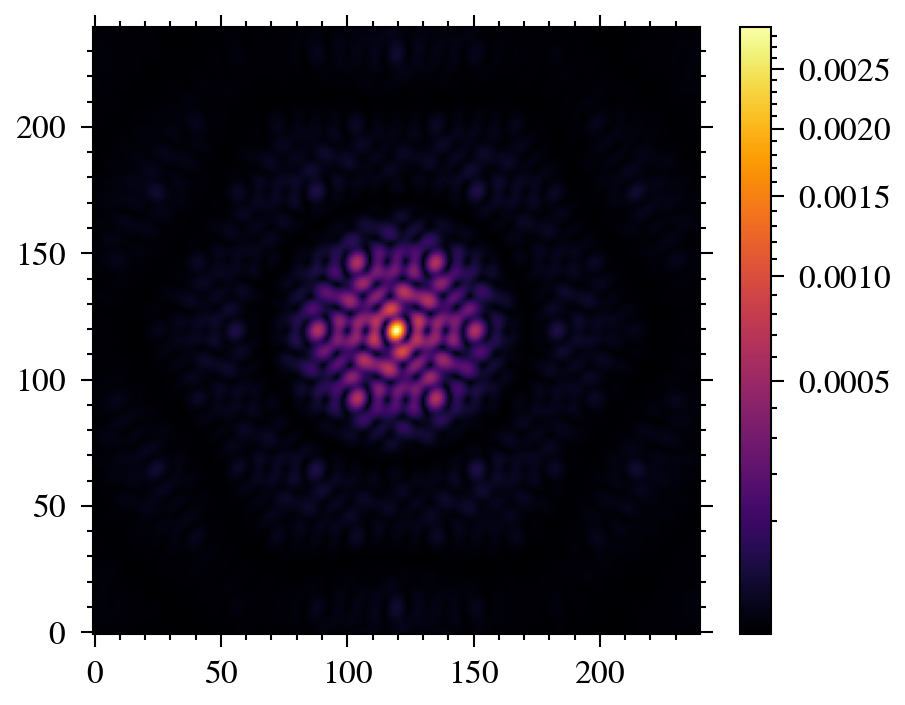

In [27]:
psf = exposure.model_psf(model)

plt.imshow(psf.data, norm=mpl.colors.PowerNorm(0.5))
plt.colorbar()
plt.show()

{'F380M': Array(0., dtype=float64), 'F430M': Array(0., dtype=float64), 'F480M': Array(0., dtype=float64)}


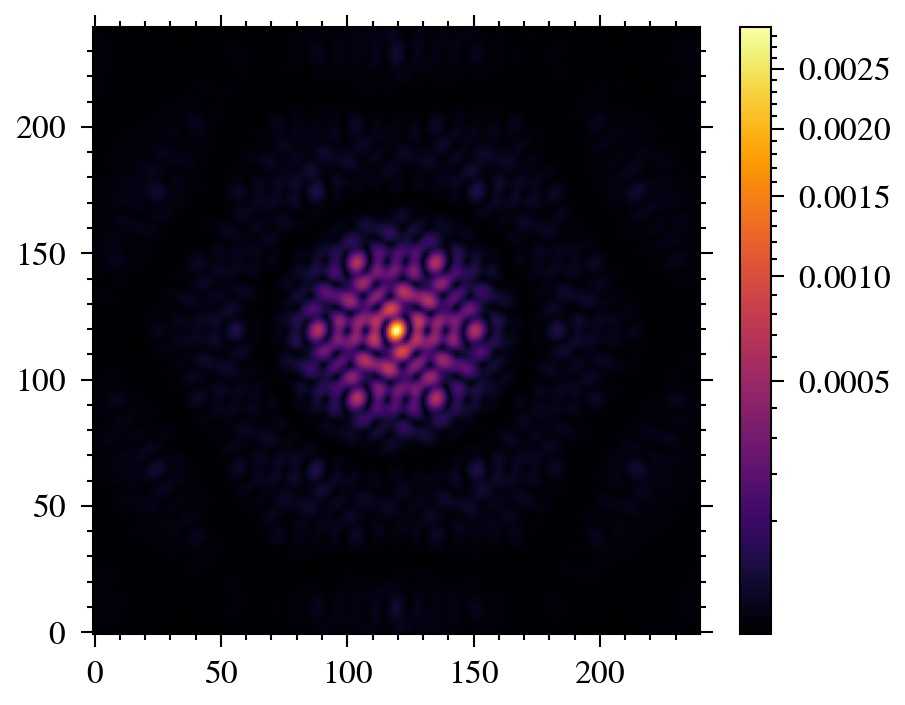

{'F380M': Array(0.5, dtype=float64), 'F430M': Array(0.5, dtype=float64), 'F480M': Array(0.5, dtype=float64)}


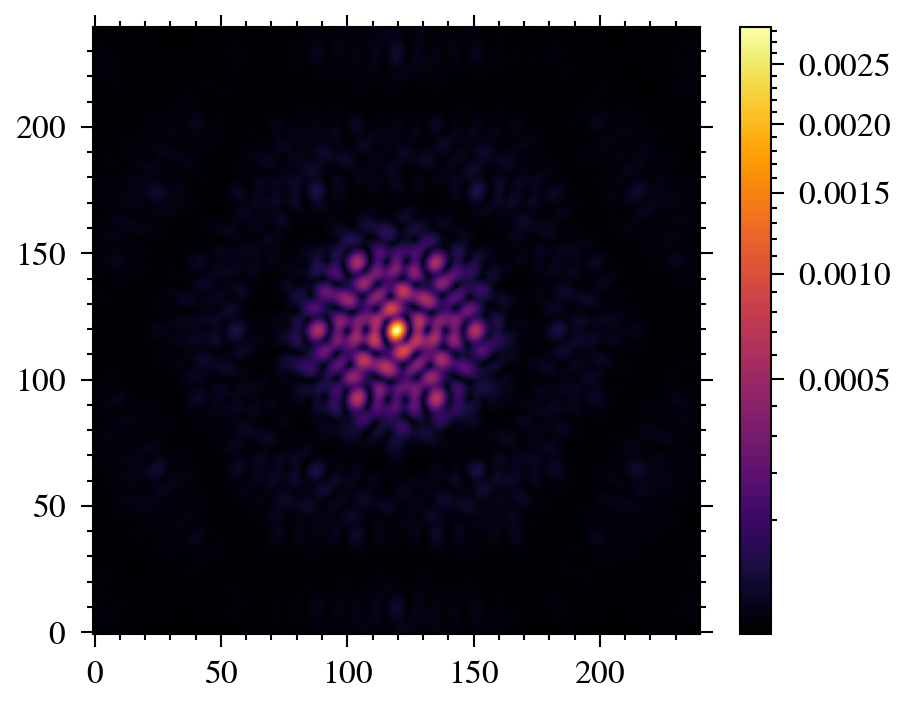

{'F380M': Array(1., dtype=float64), 'F430M': Array(1., dtype=float64), 'F480M': Array(1., dtype=float64)}


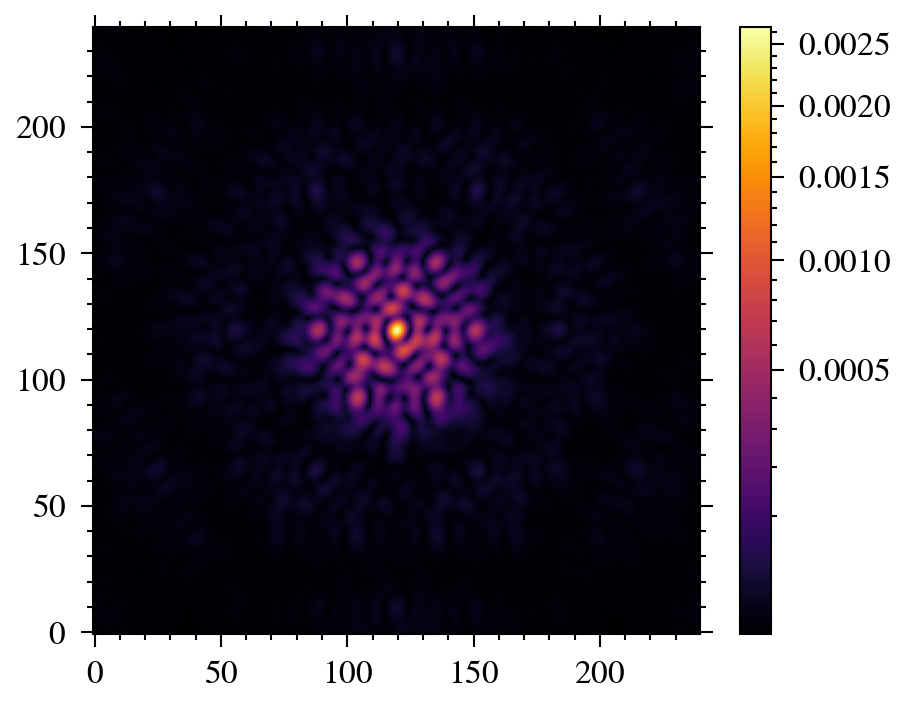

{'F380M': Array(1.5, dtype=float64), 'F430M': Array(1.5, dtype=float64), 'F480M': Array(1.5, dtype=float64)}


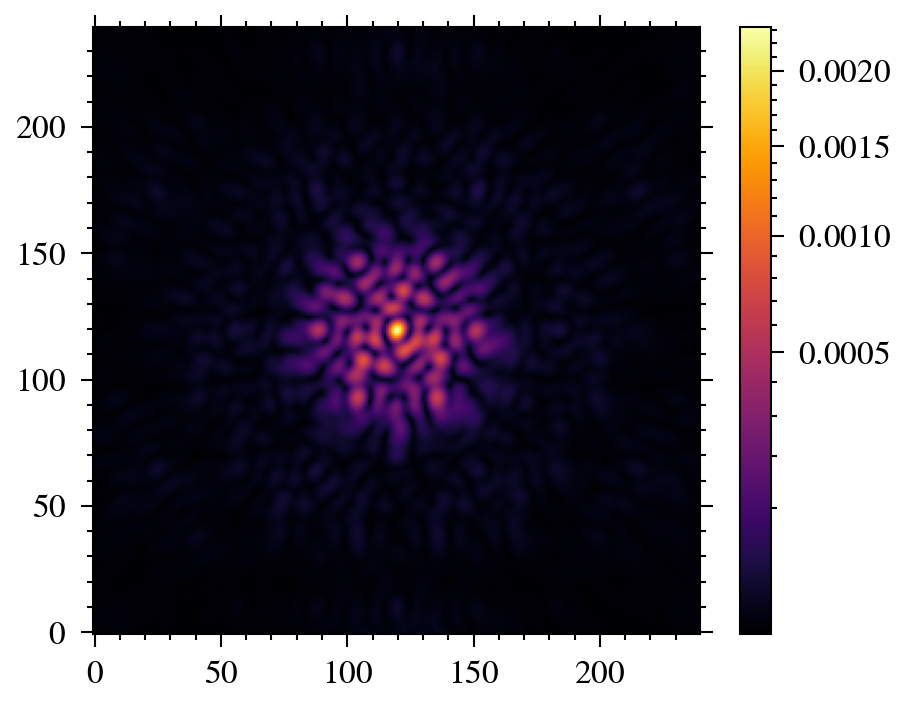

{'F380M': Array(2., dtype=float64), 'F430M': Array(2., dtype=float64), 'F480M': Array(2., dtype=float64)}


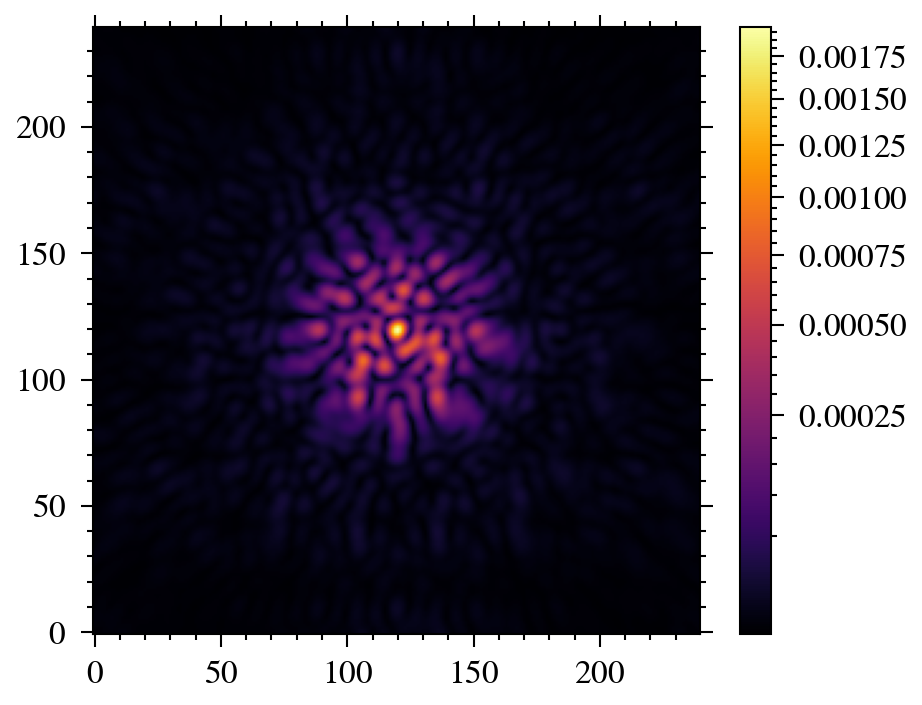

In [29]:
defoci = np.array([0.0, 0.5, 1.0, 1.5, 2.0]) * 1e0  # in metres

for defocus in defoci:
    m = model.set("defocus", jax.tree.map(lambda x: defocus, model.defocus))
    print(m.defocus)
    psf = exposure.model_psf(m)

    plt.imshow(psf.data, norm=mpl.colors.PowerNorm(0.5))
    plt.colorbar()
    plt.show()